# Connectivité Internet en Afrique
#### Analyse de la connectivité internet sur le continent africain

**Dataset :** World Internet Usage Data 2023 — Kaggle

**Objectif :** Dans ce projet, j'ai voulu comprendre comment internet
se répand en Afrique. Quels pays sont les plus connectés ? Lesquels
sont en retard ? Et où se situe la Côte d'Ivoire par rapport
au reste du continent ?

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/kanchana1990/world-internet-usage-data-2023-updated/internet_users.csv")

print(f"Dimensions : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

Dimensions : 238 lignes x 8 colonnes


,Location,Rate (WB),Year,Rate (ITU),Year.1,Users (CIA),Year.2,Notes
0,World,67.4,2023.0,67.4,2023.0,NaN,NaN,NaN
1,Afghanistan,18.4,2020.0,17.6,2019.0,7020000.0,2020.0,NaN
2,Albania,83.1,2023.0,83.1,2023.0,2291000.0,2021.0,NaN
3,Algeria,71.2,2022.0,71.2,2022.0,31240000.0,2021.0,NaN
4,American Samoa,NaN,NaN,NaN,NaN,18135.0,2021.0,NaN


In [7]:
print(df.columns.tolist())

['Location', 'Rate (WB)', 'Year', 'Rate (ITU)', 'Year.1', 'Users (CIA)', 'Year.2', 'Notes']


In [8]:
print(df.isnull().sum())

Location         0
Rate (WB)       29
Year            29
Rate (ITU)      11
Year.1          11
Users (CIA)      6
Year.2           7
Notes          236
dtype: int64


In [9]:
pays_africains = [
    "Algeria", "Angola", "Benin", "Botswana", "Burkina Faso", "Burundi",
    "Cameroon", "Cape Verde", "Central African Republic", "Chad", "Comoros",
    "Congo", "Democratic Republic of Congo", "Djibouti", "Egypt",
    "Equatorial Guinea", "Eritrea", "Eswatini", "Ethiopia", "Gabon", "Gambia",
    "Ghana", "Guinea", "Guinea-Bissau", "Ivory Coast", "Kenya", "Lesotho",
    "Liberia", "Libya", "Madagascar", "Malawi", "Mali", "Mauritania",
    "Mauritius", "Morocco", "Mozambique", "Namibia", "Niger", "Nigeria",
    "Rwanda", "Senegal", "Sierra Leone", "Somalia", "South Africa",
    "South Sudan", "Sudan", "Tanzania", "Togo", "Tunisia", "Uganda",
    "Zambia", "Zimbabwe"
]

df_afrique = df[df["Location"].isin(pays_africains)].copy()

print(f"Pays africains trouvés : {len(df_afrique)}")
print(df_afrique["Location"].unique())

Pays africains trouvés : 50
['Algeria' 'Angola' 'Benin' 'Botswana' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Cape Verde' 'Central African Republic' 'Chad' 'Comoros' 'Djibouti'
 'Egypt' 'Equatorial Guinea' 'Eritrea' 'Eswatini' 'Ethiopia' 'Gabon'
 'Gambia' 'Ghana' 'Guinea' 'Guinea-Bissau' 'Ivory Coast' 'Kenya' 'Lesotho'
 'Liberia' 'Libya' 'Madagascar' 'Malawi' 'Mali' 'Mauritania' 'Mauritius'
 'Morocco' 'Mozambique' 'Namibia' 'Niger' 'Nigeria' 'Rwanda' 'Senegal'
 'Sierra Leone' 'Somalia' 'South Africa' 'South Sudan' 'Sudan' 'Tanzania'
 'Togo' 'Tunisia' 'Uganda' 'Zambia' 'Zimbabwe']


In [10]:
df_afrique = df[df["Location"].isin(pays_africains)][["Location", "Rate (ITU)"]].copy()

df_afrique.columns = ["Pays", "Taux_Internet"]

df_afrique = df_afrique.dropna(subset=["Taux_Internet"])

print(f"Pays avec des données disponibles : {len(df_afrique)}")
print()
print(df_afrique.describe().round(2))

Pays avec des données disponibles : 50

       Taux_Internet
count          50.00
mean           42.47
std            23.04
min             7.50
25%            26.85
50%            34.95
75%            64.30
max            89.90


In [11]:
# Top 10 pays les plus connectes
top10 = df_afrique.nlargest(10, "Taux_Internet")
print("TOP 10 PAYS LES PLUS CONNECTES")
print(top10.to_string(index=False))

print()

# Position de la Cote d'Ivoire
ci = df_afrique[df_afrique["Pays"] == "Ivory Coast"]
rank = df_afrique["Taux_Internet"].rank(ascending=False)[ci.index[0]]
print(f"Pays : COTE D'IVOIRE")
print(f"Taux : {ci['Taux_Internet'].values[0]}%")
print(f"Classement : #{int(rank)} sur {len(df_afrique)} pays")
print(f"Ecart avec la moyenne : {ci['Taux_Internet'].values[0] - 42.47:+.1f}% de la moyenne africaine")

TOP 10 PAYS LES PLUS CONNECTES
        Pays  Taux_Internet
     Morocco           89.9
       Libya           88.4
    Botswana           77.3
   Mauritius           75.5
South Africa           74.7
     Tunisia           73.8
       Gabon           73.7
       Egypt           72.2
  Cape Verde           72.1
     Algeria           71.2

Pays : COTE D'IVOIRE
Taux : 38.4%
Classement : #23 sur 50 pays
Ecart avec la moyenne : -4.1% de la moyenne africaine


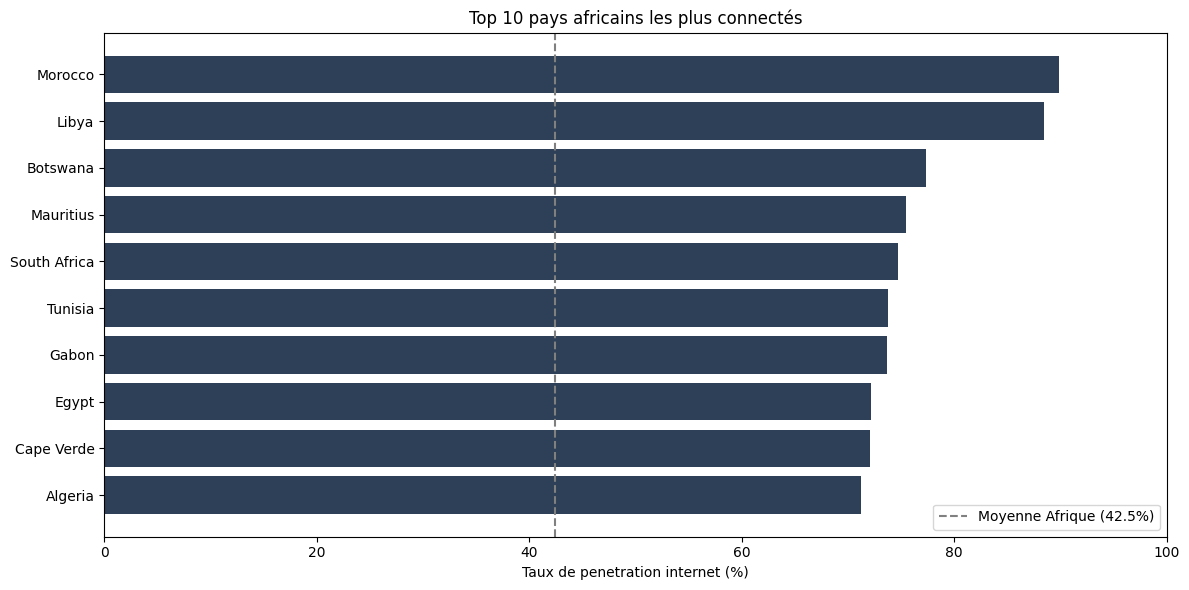

In [12]:
moyenne = df_afrique["Taux_Internet"].mean()

plt.figure(figsize=(12, 6))

colors = ["#E85C1A" if pays == "Ivory Coast" else "#2E4057" for pays in top10["Pays"]]

bars = plt.barh(top10["Pays"], top10["Taux_Internet"], color=colors)

plt.axvline(moyenne, color="gray", linestyle="--", linewidth=1.5, label=f"Moyenne Afrique ({moyenne:.1f}%)")

plt.xlabel("Taux de penetration internet (%)")
plt.title("Top 10 pays africains les plus connectés")
plt.legend()
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

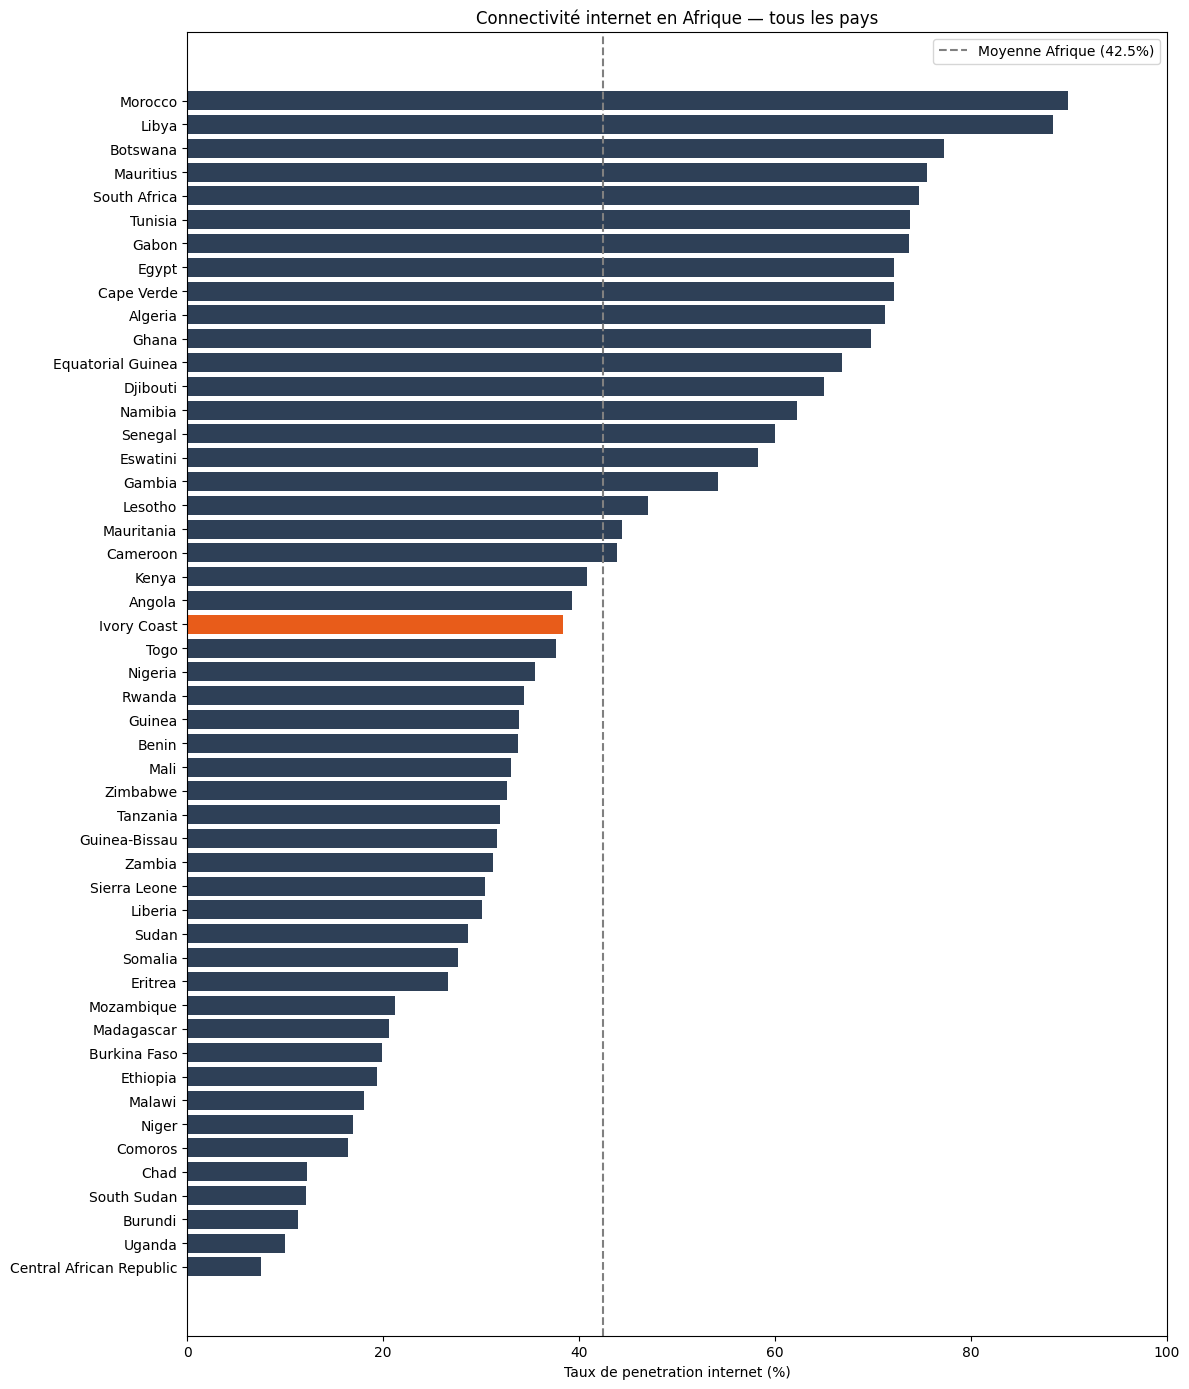

In [13]:
df_sorted = df_afrique.sort_values("Taux_Internet", ascending=True)

colors = ["#E85C1A" if pays == "Ivory Coast" else "#2E4057" for pays in df_sorted["Pays"]]

plt.figure(figsize=(12, 14))
plt.barh(df_sorted["Pays"], df_sorted["Taux_Internet"], color=colors)
plt.axvline(moyenne, color="gray", linestyle="--", linewidth=1.5, label=f"Moyenne Afrique ({moyenne:.1f}%)")
plt.xlabel("Taux de penetration internet (%)")
plt.title("Connectivité internet en Afrique — tous les pays")
plt.legend()
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

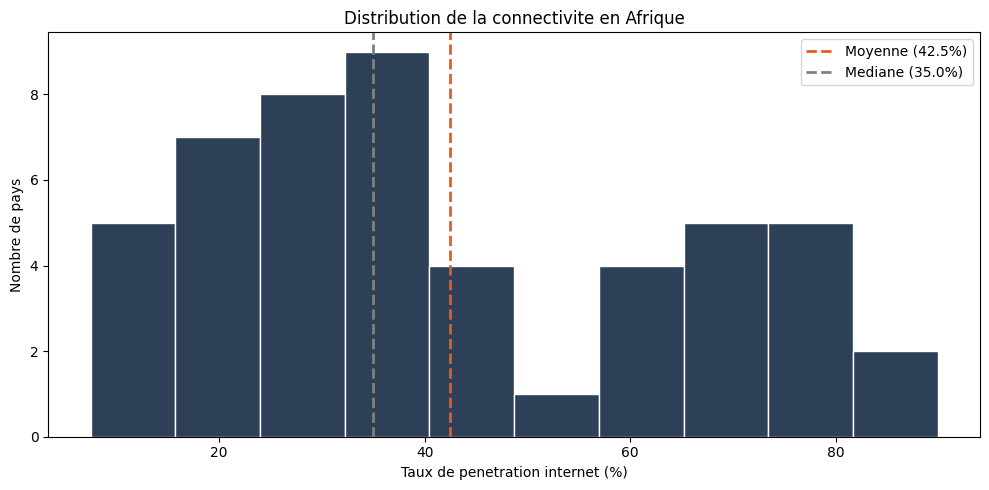

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(df_afrique["Taux_Internet"], bins=10, color="#2E4057", edgecolor="white")
plt.axvline(moyenne, color="#E85C1A", linestyle="--", linewidth=2, label=f"Moyenne ({moyenne:.1f}%)")
plt.axvline(df_afrique["Taux_Internet"].median(), color="gray", linestyle="--", linewidth=2, label=f"Mediane ({df_afrique['Taux_Internet'].median():.1f}%)")

plt.xlabel("Taux de penetration internet (%)")
plt.ylabel("Nombre de pays")
plt.title("Distribution de la connectivite en Afrique")
plt.legend()
plt.tight_layout()
plt.show()

Ce graphique montre comment les 50 pays africains se repartissent
selon leur taux de penetration internet.

Chaque barre represente un groupe de pays ayant un taux similaire.

**Ce qu'on observe :**
- La majorité des pays (14) se concentre entre 30% et 40%
- 10 pays sont encore en dessous de 20% — ce sont les pays les plus en retard
- 2 pays depassent 80% : le Maroc (89.9%) et la Libye (88.4%) — ce sont les leaders du continent
- La mediane (35%) est inferieure a la moyenne (42.5%) ce qui signifie
  que quelques pays trés connectés tirent la moyenne vers le haut

**En clair :** Plus de la moitié des pays africains ont moins de 35%
de leur population connectée a internet.

## Conclusions

### Ce que les données nous disent

1. **Une Afrique à deux vitesses** — Le Maroc et la Libye dépassent 88%
de pénétration tandis que la République Centrafricaine plafonne à 7.5%.
L'écart entre le pays le plus connecté et le moins connecté est de 82 points.

2. **La moitié de l'Afrique est encore déconnectée** — Avec une médiane
à 35%, plus de la moitié des pays africains ont moins d'un tiers de leur
population connectée.

3. **La Côte d'Ivoire dans la moyenne** — Avec 38.4% la Côte d'Ivoire
se classe 23ème sur 50 pays. Elle n'est pas en retard critique mais elle
n'est pas encore parmi les leaders.

4. **Un potentiel de croissance immense** — Les 10 pays sous 20% de
connectivité représentent des millions de personnes non connectées,
un marché énorme pour les années à venir.